<a href="https://colab.research.google.com/github/Dkaushani/AML_Fraud_Detection_Risk_Scoring_Model/blob/main/Fraud_Detection_Risk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install SHAP for model explainability
!pip install shap xgboost -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools for preprocessing, split, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

# XGBoost for supervised classification
import xgboost as xgb

# SHAP for model interpretability (Crucial for compliance & risk audits)
import shap

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

# 1. Replace 'YOUR_KAGGLE_USERNAME' with your actual Kaggle username
os.environ['KAGGLE_USERNAME'] = "YOUR_KAGGLE_USERNAME"

# 2. Set your Kaggle Access Token
os.environ['KAGGLE_KEY'] = "KGAT_0b57a66959693796a4a4707a42da8257"

# 3. Download and unzip the PaySim dataset directly via the Kaggle CLI
!kaggle datasets download -d ealaxi/paysim1
!unzip -o paysim1.zip

print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:01<00:00, 114MB/s]

Archive:  paysim1.zip
  inflating: PS_20174392719_1491204439457_log.csv  
Dataset downloaded and unzipped successfully!


In [5]:
import os
import glob
import pandas as pd

# Check what files exist in the current directory
files = os.listdir('.')
print("Files in current Colab directory:", files)

# Find any CSV file automatically
csv_files = glob.glob('*.csv')

if csv_files:
    target_file = csv_files[0]
    print(f"\nFound CSV file: '{target_file}'")

    # Load the dataset using the dynamically matched filename
    df = pd.read_csv(target_file)
    print(f"\nDataset Shape: {df.shape}")
    print("\nFirst 5 rows:")
    print(df.head())

    print("\nClass distribution (0 = Normal, 1 = Fraud):")
    print(df['isFraud'].value_counts(normalize=True))
else:
    print("\nNo CSV file found! The unzip command might have failed or the dataset wasn't downloaded.")

Files in current Colab directory: ['.config', 'paysim1.zip', 'PS_20174392719_1491204439457_log.csv', 'sample_data']

Found CSV file: 'PS_20174392719_1491204439457_log.csv'

Dataset Shape: (6362620, 11)

First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0      

In [6]:
# 1. Filter for high-risk transaction types
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# 2. Engineer AML Domain Features
# Feature A: Discrepancy in sender balance (Expected vs Actual)
df_filtered['errorBalanceOrig'] = df_filtered['newbalanceOrig'] + df_filtered['amount'] - df_filtered['oldbalanceOrg']

# Feature B: Discrepancy in receiver balance (Expected vs Actual)
df_filtered['errorBalanceDest'] = df_filtered['oldbalanceDest'] + df_filtered['amount'] - df_filtered['newbalanceDest']

# Feature C: Ratio of transfer relative to initial balance
df_filtered['amount_to_oldbalance_ratio'] = df_filtered['amount'] / (df_filtered['oldbalanceOrg'] + 1)

# 3. One-Hot Encode transaction type (TRANSFER vs CASH_OUT)
df_filtered = pd.get_dummies(df_filtered, columns=['type'], drop_first=True)

# 4. Select numerical features for modeling (dropping string IDs like nameOrig/nameDest)
feature_cols = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'amount_to_oldbalance_ratio', 'type_TRANSFER'
]

X = df_filtered[feature_cols]
y = df_filtered['isFraud']

print(f"Filtered Dataset Shape: {X.shape}")
print("Feature Engineering Complete! Preview of engineered columns:")
X[['errorBalanceOrig', 'errorBalanceDest', 'amount_to_oldbalance_ratio']].head()

Filtered Dataset Shape: (2770409, 9)
Feature Engineering Complete! Preview of engineered columns:


,errorBalanceOrig,errorBalanceDest,amount_to_oldbalance_ratio
2,0.00,181.0,0.994505
3,0.00,21363.0,0.994505
15,213808.94,182703.5,14.950668
19,214605.30,237735.3,304.972096
24,300850.89,-2401220.0,28.763925


In [7]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")
print(f"Fraud cases in training set: {y_train.sum():,}")
print(f"Fraud cases in test set: {y_test.sum():,}")

Training set size: 2,216,327 samples
Test set size: 554,082 samples
Fraud cases in training set: 6,570
Fraud cases in test set: 1,643


In [8]:
from sklearn.ensemble import IsolationForest

print("Fitting Isolation Forest on representative sample...")

# 1. Sample 100k records to fit the forest efficiently
X_sample_iso = X_train.sample(n=100000, random_state=42)

# 2. Initialize Isolation Forest
# contamination=0.003 aligns closely with expected transaction anomaly rate (~0.3%)
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.003,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_sample_iso)

print("Calculating anomaly scores for full train and test sets...")

# 3. Get decision function scores (lower/more negative scores indicate higher anomaly risk)
# Note: Using .copy() prevents pandas SettingWithCopy Warning
X_train = X_train.copy()
X_test = X_test.copy()

X_train['anomaly_score'] = iso_forest.decision_function(X_train)
X_test['anomaly_score'] = iso_forest.decision_function(X_test)

print("Isolation Forest anomaly scores added successfully!")
print("Sample anomaly scores preview:")
print(X_train[['amount', 'errorBalanceOrig', 'anomaly_score']].head())

Fitting Isolation Forest on representative sample...
Calculating anomaly scores for full train and test sets...
Isolation Forest anomaly scores added successfully!
Sample anomaly scores preview:
            amount  errorBalanceOrig  anomaly_score
5359676   71884.81      7.188481e+04       0.405777
5539126  222936.06      5.820766e-11       0.317926
2188719  284645.66      2.840597e+05       0.404100
2594313  239069.35      2.289024e+05       0.403507
421860   193796.39      1.937964e+05       0.356054


In [9]:
import xgboost as xgb

# 1. Calculate the imbalance ratio for loss weight adjustment
ratio = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Calculated scale_pos_weight ratio: {ratio:.2f}")

# 2. Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    tree_method='hist', # Uses fast histogram-based algorithm optimized for large datasets
    random_state=42,
    n_jobs=-1
)

# 3. Train XGBoost model
print("Training XGBoost AML Risk Model...")
xgb_model.fit(X_train, y_train)

print("XGBoost Model successfully trained!")

Calculated scale_pos_weight ratio: 336.34
Training XGBoost AML Risk Model...
XGBoost Model successfully trained!


In [10]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predict continuous risk probabilities (0.0 to 1.0)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Convert probabilities to binary predictions using standard 0.5 threshold
y_preds = (y_probs > 0.5).astype(int)

# 1. Compute ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_probs)
print(f"=== MODEL EVALUATION METRICS ===")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# 2. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_preds, digits=4))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:")
print(f"True Negatives (Normal flagged as Normal): {cm[0][0]:,}")
print(f"False Positives (Normal falsely flagged as Fraud): {cm[0][1]:,}")
print(f"False Negatives (Fraud missed): {cm[1][0]:,}")
print(f"True Positives (Fraud caught): {cm[1][1]:,}")

=== MODEL EVALUATION METRICS ===
ROC-AUC Score: 0.9989

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999    552439
           1     0.9233    0.9963    0.9584      1643

    accuracy                         0.9997    554082
   macro avg     0.9616    0.9981    0.9792    554082
weighted avg     0.9998    0.9997    0.9997    554082

Confusion Matrix:
True Negatives (Normal flagged as Normal): 552,303
False Positives (Normal falsely flagged as Fraud): 136
False Negatives (Fraud missed): 6
True Positives (Fraud caught): 1,637


In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predict continuous risk probabilities (0.0 to 1.0)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Convert probabilities to binary predictions using standard 0.5 threshold
y_preds = (y_probs > 0.5).astype(int)

# 1. Compute ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_probs)
print(f"=== MODEL EVALUATION METRICS ===")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# 2. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_preds, digits=4))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:")
print(f"True Negatives (Normal flagged as Normal): {cm[0][0]:,}")
print(f"False Positives (Normal falsely flagged as Fraud): {cm[0][1]:,}")
print(f"False Negatives (Fraud missed): {cm[1][0]:,}")
print(f"True Positives (Fraud caught): {cm[1][1]:,}")

=== MODEL EVALUATION METRICS ===
ROC-AUC Score: 0.9989

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999    552439
           1     0.9233    0.9963    0.9584      1643

    accuracy                         0.9997    554082
   macro avg     0.9616    0.9981    0.9792    554082
weighted avg     0.9998    0.9997    0.9997    554082

Confusion Matrix:
True Negatives (Normal flagged as Normal): 552,303
False Positives (Normal falsely flagged as Fraud): 136
False Negatives (Fraud missed): 6
True Positives (Fraud caught): 1,637


In [12]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize TreeExplainer optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb_model)

# 2. Sample 1,000 instances from X_test for efficient computation
X_test_sample = X_test.sample(n=1000, random_state=42)

# 3. Calculate SHAP values (returns explanations object)
shap_values = explainer(X_test_sample)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


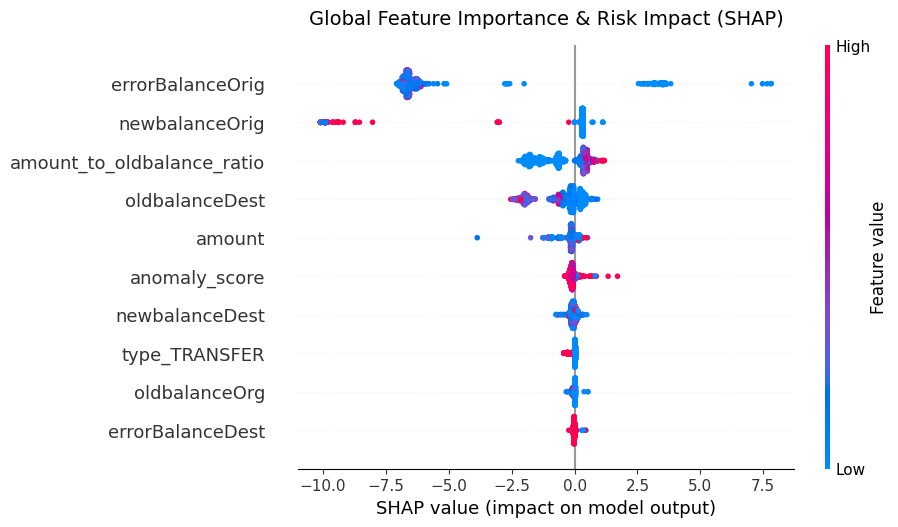

In [13]:
# Create SHAP Beeswarm Summary Plot
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance & Risk Impact (SHAP)", fontsize=14, pad=15)
shap.plots.beeswarm(shap_values, max_display=10)

=== FLAGGED TRANSACTION DETAILS ===
                               3939555
amount                      2674794.22
oldbalanceOrg               2674794.22
newbalanceOrig                     0.0
oldbalanceDest              1380829.87
newbalanceDest              4055624.09
errorBalanceOrig                   0.0
errorBalanceDest                   0.0
amount_to_oldbalance_ratio         1.0
type_TRANSFER                    False
anomaly_score                  0.13352

Model Output Fraud Probability Score: 0.9997


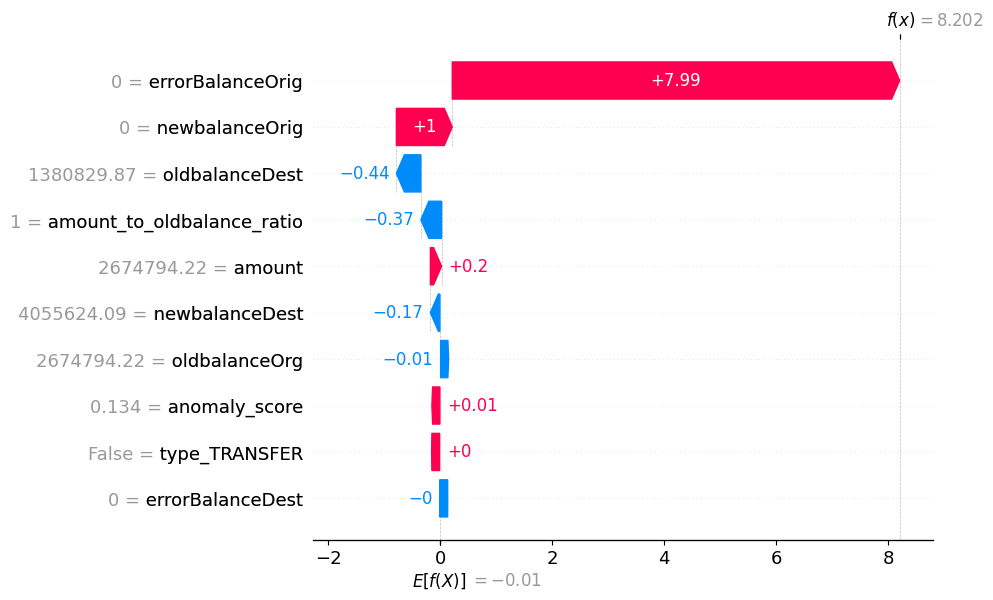

In [14]:
# 1. Locate a confirmed fraud transaction in the test set
fraud_indices = y_test[y_test == 1].index
sample_fraud_idx = fraud_indices[0]

# 2. Get the feature values for this specific transaction
single_tx = X_test.loc[[sample_fraud_idx]]
single_shap = explainer(single_tx)

# 3. Print actual input values for context
print("=== FLAGGED TRANSACTION DETAILS ===")
print(single_tx.T)
print(f"\nModel Output Fraud Probability Score: {xgb_model.predict_proba(single_tx)[0][1]:.4f}")

# 4. Plot Waterfall Explanation for this specific transaction
plt.figure(figsize=(8, 6))
shap.plots.waterfall(single_shap[0])

     AML TRANSACTION RISK AUDIT REPORT    
Risk Tier        : LOW RISK - PASS
Fraud Probability : 0.14%
------------------------------------------


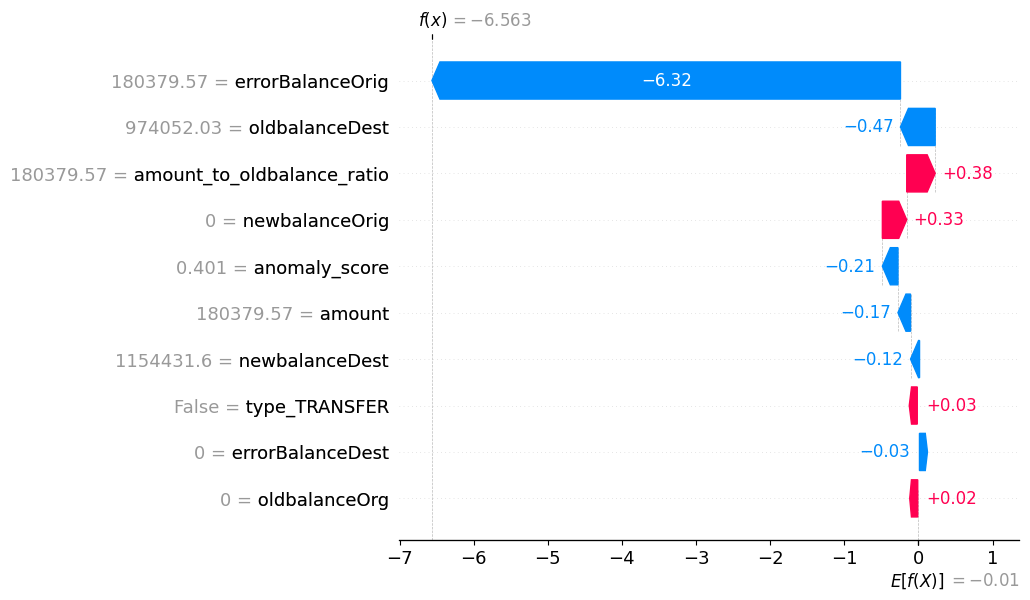

In [15]:
def generate_aml_risk_report(transaction_df, model, explainer):
    """
    Takes a pandas DataFrame row representing a new transaction,
    returns the Risk Score (%) and primary risk drivers.
    """
    # Predict risk probability
    risk_prob = model.predict_proba(transaction_df)[0][1]
    risk_percentage = risk_prob * 100

    # Risk Classification Tier
    if risk_percentage >= 70:
        risk_tier = "HIGH RISK - IMMEDIATE FREEZE & INVESTIGATION"
    elif risk_percentage >= 30:
        risk_tier = "MEDIUM RISK - ENHANCED DUE DILIGENCE (EDD)"
    else:
        risk_tier = "LOW RISK - PASS"

    print("==========================================")
    print("     AML TRANSACTION RISK AUDIT REPORT    ")
    print("==========================================")
    print(f"Risk Tier        : {risk_tier}")
    print(f"Fraud Probability : {risk_percentage:.2f}%")
    print("------------------------------------------")

    # Generate SHAP waterfall plot explanation
    shap_single = explainer(transaction_df)
    shap.plots.waterfall(shap_single[0])

# Example usage on an unseen transaction:
random_tx = X_test.sample(1, random_state=7)
generate_aml_risk_report(random_tx, xgb_model, explainer)